### Helper functions

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
from scipy.optimize import linprog
from scipy.stats import norm

# Probability of success
def p_success(x, mode='linear'):
    if(mode == 'linear'):
        # Linear scaling from 0.0 to 1.0 over the score range
        return np.clip((x - X_MIN) / (X_MAX - X_MIN), 0, 1)
    else: #logistic
        return 1 / (1 + np.exp(-0.4 * (x-(X_MAX-X_MIN)/2)))  ##need to check this and add X_min and X_max, the logistic prob distribution originally used by Gemini

def check_assumptions(params):
    """Verifies that parameters satisfy paper assumptions."""
    ratio_u = params['U_PLUS'] / params['U_MINUS']
    ratio_c = params['C_PLUS'] / params['C_MINUS']
    print(f"Assumption 2 Check: {ratio_u:.2f} > {ratio_c:.2f} ?")
    if ratio_u > ratio_c:
        print("✅ Assumption 2 Satisfied.")
    else:
        print("❌ Assumption 2 VIOLATED. Change Parameters.")
        print('U+=',params['U_PLUS'])
        print('U-=',params['U_MINUS'])
        print('C+=',params['C_PLUS'])
        print('C-=',params['C_MINUS'])

def generate_distribution(mu, sigma):
    """Generates a discrete integer distribution (Approximated Gaussian)."""
    x_values = np.arange(X_MIN, X_MAX + 1)
    # PDF of normal dist
    probs = norm.pdf(x_values, mu, sigma)
    # Normalize to sum to 1 over the integer support
    probs /= probs.sum()
    return probs

# function to compute u(x) and c(x) from the parameters
def get_metrics(x, params, p_mode='linear'):
    check_assumptions(params)
    p = p_success(x)
    eu = p * params['U_PLUS'] + (1 - p) * params['U_MINUS']
    ed = p * params['C_PLUS'] + (1 - p) * params['C_MINUS']
    return eu, ed

def get_data(mode='synthetic'):
    if mode == 'synthetic':
        # Synthetic Populations: Group A better than B from gaussian distributions
        # Discretized distributions
        dist_A = generate_distribution(MEAN_Adv_group, sigma); dist_A /= dist_A.sum()
        dist_B = generate_distribution(MEAN_disAdv_group, sigma);  dist_B /= dist_B.sum()
    elif mode == 'real':
        return get_real_data()
    else:
        pass  # to be implemented for real-world datasets

    #print(dist_A)
    #print(sum(dist_A))
    return dist_A, dist_B

#code copy-pasted from fairml book: https://github.com/fairmlbook/fairmlbook.github.io/tree/master/code/creditscore/data
#the version used here is adopted from https://github.com/lydiatliu/delayedimpact/blob/master/notebooks/FICO-figures.ipynb
def get_real_data():
    # Adjust these as needed
    DATA_DIR='./fico-score/data/'
    FIGURE_DIR='./fico-score/figures/'

    def cleanup_frame(frame):
        """Rename and re-order columns"""
        frame = frame.rename(columns={'Non- Hispanic white': 'White'})
        frame = frame.reindex(['Asian', 'Black', 'Hispanic', 'White'], axis=1)
        return frame

    def read_totals():
        """Read the total number of people of each race"""
        frame = cleanup_frame(pd.read_csv(DATA_DIR+files['overall'], index_col=0))
        return {r:frame[r]['SSA'] for r in frame.columns}

    def parse_data(data_dir=DATA_DIR):
        """Parse sqf data set."""

        cdfs = cleanup_frame(pd.read_csv(data_dir+files['cdf_by_race'], index_col=0))
        performance = 100-cleanup_frame(pd.read_csv(data_dir+files['performance_by_race'], index_col=0))
        return (cdfs/100., performance/100.)

    files = dict(cdf_by_race = 'transrisk_cdf_by_race_ssa.csv',
                 performance_by_race = 'transrisk_performance_by_race_ssa.csv',
                 overall = 'totals.csv')

    cdfs = cleanup_frame(pd.read_csv(DATA_DIR+files['cdf_by_race'], index_col=0))
    performance = 100-cleanup_frame(pd.read_csv(DATA_DIR+files['performance_by_race'], index_col=0))

    cdfs = cdfs[["White","Black"]]
    performance = performance[["White","Black"]]

    cdf_B = cdfs['White'].values
    cdf_A = cdfs['Black'].values

    repay_B = performance['White']
    repay_A = performance['Black']

    scores = cdfs.index
    scores_list = scores.tolist()
    scores_repay = cdfs.index

    # to populate group distributions
    def get_pmf(cdf):
        pis = np.zeros(cdf.size)
        pis[0] = cdf[0]
        for score in range(cdf.size-1):
            pis[score+1] = cdf[score+1] - cdf[score]
        return pis

    # to get loan repay probabilities for a given score
    loan_repaid_probs = [lambda i: repay_A[scores[scores.get_loc(i,method='nearest')]],
                         lambda i: repay_B[scores[scores.get_loc(i,method='nearest')]]]

    # basic parameters
    N_scores = cdf_B.size
    N_groups = 2

    # get probability mass functions of each group
    pi_A = get_pmf(cdf_A)
    pi_B = get_pmf(cdf_B)

    return pi_A/100, pi_B/100

def solve_opt_fair(alpha, input_dist, x_values, eu_vals, ed_vals, speed='normal'):
    '''Implementation wit randomizing at the threshold'''
    # read the distributions
    dist_A = input_dist[0]
    dist_B = input_dist[1]

    n = len(x_values)

    scores = x_values

    best_fair_u = -np.inf
    assignment_flag = False

    # Discretize randomization probabilities at the threshold
    # Using 11 steps for 0.0, 0.1, ..., 1.0 to approximate continuous probabilities
    if(speed=='fast'):
        p_random_steps = np.linspace(0.0, 1.0, 2)
    else:
        p_random_steps = np.linspace(0.0, 1.0, 11)

    # Calculate initial means for fairness constraint, as they are constant
    mu_A_init = np.sum(dist_A * scores)
    mu_B_init = np.sum(dist_B * scores)

    # Search over all possible threshold pairs (t_A, t_B)
    # Policy: Select if score > t, with probability p if score == t
    # TODO: X_MAX is a global variable; make the logic independent of it
    t_A_star = None
    t_B_star = None
    for t_A in tqdm(range(X_MAX + 2), desc="Searching Threshold A"): # tqdm for outer loop
        for t_B in range(X_MAX + 2):
            for p_A_at_tA in p_random_steps:
                for p_B_at_tB in p_random_steps:

                    pi_A_policy = np.zeros_like(scores, dtype=float)
                    pi_A_policy[scores > t_A] = 1.0
                    pi_A_policy[scores == t_A] = p_A_at_tA

                    pi_B_policy = np.zeros_like(scores, dtype=float)
                    pi_B_policy[scores > t_B] = 1.0
                    pi_B_policy[scores == t_B] = p_B_at_tB

                    # Check Fairness Constraint: |Mean_A_new - Mean_B_new| <= alpha
                    # New Mean = Old Mean + Expected Change
                    change_A = np.sum(dist_A * pi_A_policy * ed_vals)
                    change_B = np.sum(dist_B * pi_B_policy * ed_vals)

                    mu_A_new = mu_A_init + change_A
                    mu_B_new = mu_B_init + change_B

                    if abs(mu_A_new - mu_B_new) <= alpha*(X_MAX-X_MIN):
                        # Using global weights W_A and W_B for utility calculation
                        u_curr = W_A * np.sum(dist_A * pi_A_policy * eu_vals) + W_B * np.sum(dist_B * pi_B_policy * eu_vals)
                        if u_curr > best_fair_u:
                            best_fair_u = u_curr
                            t_A_star = t_A
                            t_B_star = t_B
                            assignment_flag = True

    if not assignment_flag:
        return None, None

    return best_fair_u, [t_A_star, t_B_star]

def solve_opt_fair_LP(alpha, input_dist, x_values, eu_vals, ed_vals):
    """
    Solves for the policy pi(x) that maximizes utility subject to fairness alpha.
    Uses Linear Programming.

    Variables: [pi_A(0)...pi_A(MAX), pi_B(0)...pi_B(MAX)]
    Bounds: 0 <= pi <= 1
    """
    #to be consistent with the other code
    alpha = alpha*(X_MAX-X_MIN)

    # read the distributions
    dist_A = input_dist[0]
    dist_B = input_dist[1]

    n = len(x_values)

    # Objective: Maximize Total Utility
    # Scipy minimizes, so we minimize negative utility.
    # Obj = W_A * Sum(pi_A * D_A * EU) + W_B * Sum(pi_B * D_B * EU)
    c = -1 * np.concatenate([W_A * dist_A * eu_vals, W_B * dist_B * eu_vals])

    # Constraint: Fairness |mu'_A - mu'_B| <= alpha
    # mu'_g = mu_g_init + Sum(pi_g * D_g * E_Delta)
    mu_A_init = np.sum(x_values * dist_A)
    mu_B_init = np.sum(x_values * dist_B)

    # Coefficients for the change in mean (Delta terms)
    # We need: (mu_A_init + change_A) - (mu_B_init + change_B) <= alpha
    #      => Sum(coeff_A) - Sum(coeff_B) <= alpha - (mu_A_init - mu_B_init)
    # AND: (mu_B_init + change_B) - (mu_A_init + change_A) <= alpha
    #      => -Sum(coeff_A) + Sum(coeff_B) <= alpha - (mu_B_init - mu_A_init)

    A_fairness = np.zeros((2, 2*n))

    # Coeffs for pi_A terms (Group A change)
    A_fairness[0, :n] = dist_A * ed_vals
    A_fairness[1, :n] = -1 * dist_A * ed_vals

    # Coeffs for pi_B terms (Group B change)
    A_fairness[0, n:] = -1 * dist_B * ed_vals
    A_fairness[1, n:] = dist_B * ed_vals

    b_fairness = np.array([
        alpha - (mu_A_init - mu_B_init),
        alpha - (mu_B_init - mu_A_init)
    ])

    # Bounds for pi (0 to 1)
    bounds = [(0, 1) for _ in range(2*n)]

    # Solve
    res = linprog(c, A_ub=A_fairness, b_ub=b_fairness, bounds=bounds, method='highs')

    if res.success:
        max_utility = -res.fun # Negate back to positive
        return max_utility, res.x # Utility, Policy Vector
    else:
        return None, None # Infeasible (constraint too tight)

def solve_pof(alpha, input_dist, x_values, eu_vals, ed_vals, mode='LP', speed='normal'):

    # 1. Optimal Unconstrained Utility
    # Select everyone with Eu > 0
    pi_opt = (eu_vals > 0).astype(float)

    # read the distributions
    dist_A = input_dist[0]
    dist_B = input_dist[1]

    opt_util = W_A * np.sum(dist_A * pi_opt * eu_vals) + W_B * np.sum(dist_B * pi_opt * eu_vals)

    if(mode == 'LP'):
        # 2. Fair Optimal with LP
        fair_util, _ = solve_opt_fair_LP(alpha, input_dist, x_values, eu_vals, ed_vals)
    elif mode == 'Search':
        # 2. Optimal Fair Utility (Grid Search for Thresholds)
        fair_util, _ = solve_opt_fair(alpha, input_dist, x_values, eu_vals, ed_vals, speed)


    if fair_util is None:
        #print('alpha=', alpha)
        #print('fair util is None')
        return None # Max penalty or undefined

    if opt_util == 0:
        #print('alpha=', alpha)
        #print('fair util is None')
        return None # Max penalty or undefined

    if fair_util < 0:
        #print('alpha=', alpha)
        #print(fair_util)
        return 1

    # PoF Definition: 1 - (Fair / OPT)
    return 1 - (fair_util / opt_util)

## Experiment 1: Price of Fairness (PoF) vs Alpha ---

Assumption 2 Check: -1.00 > -2.00 ?
✅ Assumption 2 Satisfied.


100%|█████████████████████████████████████████| 50/50 [00:00<00:00, 2051.37it/s]


Assumption 2 Check: -0.10 > -0.20 ?
✅ Assumption 2 Satisfied.


100%|█████████████████████████████████████████| 50/50 [00:00<00:00, 1962.17it/s]


Assumption 2 Check: -0.50 > -0.50 ?
❌ Assumption 2 VIOLATED. Change Parameters.
U+= 1
U-= -2
C+= 7
C-= -14


100%|█████████████████████████████████████████| 50/50 [00:00<00:00, 2301.25it/s]


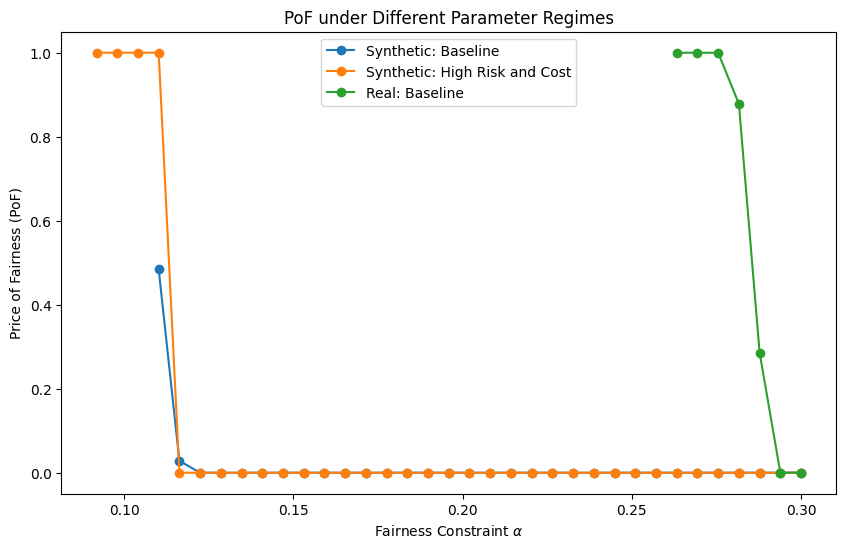

In [54]:

# --- Experiment 1: Price of Fairness Analysis for both real and synthetic data ---
def run_pof_experiment(mode='synthetic'):
    x = np.arange(X_MIN, X_MAX + 1)
    if(mode == 'synthetic'):
        input_dist = get_data('synthetic')
    else:
        input_dist = get_data('real')
    alphas = np.linspace(0, 0.3, 50)
    for cfg in configs:
        eu, ed = get_metrics(x, cfg, cfg['p'])

        pofs = []
        realized_alphas = []
        for alpha in tqdm(alphas):
            this_pof = solve_pof(alpha, input_dist, x, eu, ed, mode='LP', speed='fast')
            if this_pof is not None:
                pofs.append(this_pof)
                realized_alphas.append(alpha)

        #print(pofs)
        plt.plot(realized_alphas, pofs, marker='o', label=cfg['name'])

plt.figure(figsize=(10, 6))
#synthetic configuration
np.random.seed(1066)
X_MIN = 0
X_MAX = 100
W_A = 0.7 #weight of group A
W_B = 1-W_A #weight of group B
MEAN_Adv_group = 80
MEAN_disAdv_group = 60
sigma = 30
configs = [
    {'name': 'Synthetic: Baseline', 'U_PLUS': 2, 'U_MINUS': -2, 'C_PLUS': 2, 'C_MINUS': -1, 'p': 'linear'},
    {'name': 'Synthetic: High Risk and Cost', 'U_PLUS': 2, 'U_MINUS': -20, 'C_PLUS': 2, 'C_MINUS': -10, 'p': 'linear'},
]

run_pof_experiment('synthetic')

#real configuration
X_MAX = 197
configs = [
    {'name': 'Real: Baseline', 'U_PLUS': 1, 'U_MINUS': -2, 'C_PLUS': 7, 'C_MINUS': -14, 'p': 'linear'},
]
run_pof_experiment('real')

plt.xlabel(r'Fairness Constraint $\alpha$')
plt.ylabel('Price of Fairness (PoF)')
plt.title('PoF under Different Parameter Regimes')
plt.legend()
plt.show()

## Experiment 2: Robustness of Assumption 2 ---

Searching Threshold A: 100%|█████████████████| 102/102 [00:00<00:00, 220.45it/s]

Searching Threshold A: 100%|█████████████████| 102/102 [00:00<00:00, 248.82it/s]

Searching Threshold A: 100%|█████████████████| 102/102 [00:00<00:00, 233.59it/s]

Searching Threshold A: 100%|█████████████████| 102/102 [00:00<00:00, 236.41it/s]

Searching Threshold A: 100%|█████████████████| 102/102 [00:00<00:00, 254.41it/s]

Searching Threshold A: 100%|█████████████████| 102/102 [00:00<00:00, 238.82it/s]

Searching Threshold A: 100%|█████████████████| 102/102 [00:00<00:00, 226.78it/s]

Searching Threshold A: 100%|█████████████████| 102/102 [00:00<00:00, 231.87it/s]

Searching Threshold A: 100%|█████████████████| 102/102 [00:00<00:00, 214.83it/s]

Searching Threshold A: 100%|█████████████████| 102/102 [00:00<00:00, 183.45it/s]

Searching Threshold A: 100%|█████████████████| 102/102 [00:00<00:00, 219.20it/s]

Searching Threshold A: 100%|█████████████████| 102/102 [00:00<00:00, 217.57it/s]

Searching Thresh

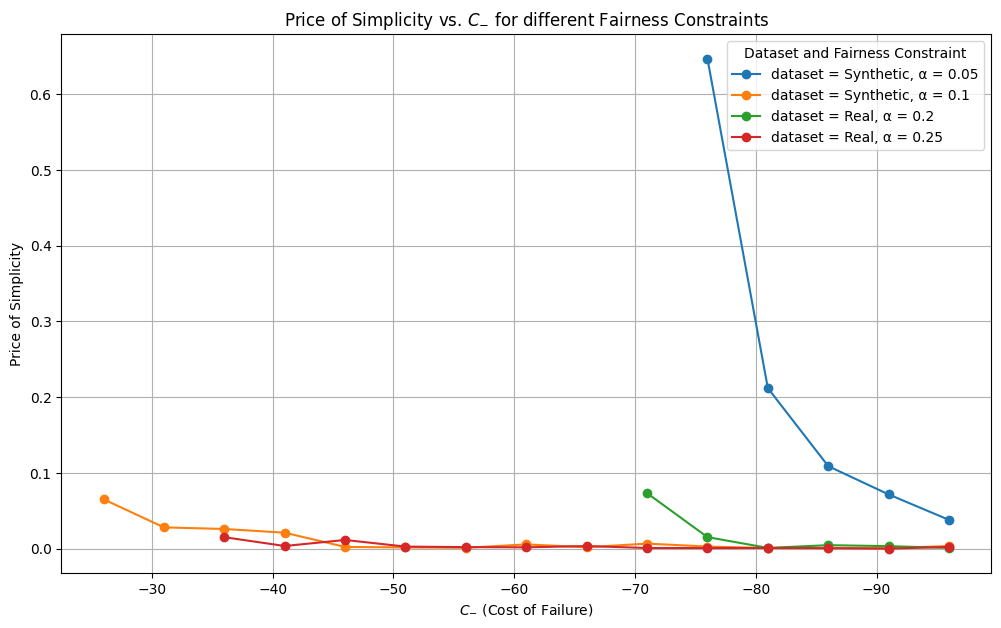

'\n#fast implementation\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport sys\n\ndef run_robustness_check(alphas_to_plot, C_MINUS_range, speed=\'fast\', mode=\'Synthetic\'):\n\n    pos_results = {alpha: [] for alpha in alphas_to_plot}\n\n    # Prepare data for calculations\n    x_values = np.arange(X_MIN, X_MAX + 1)\n    if(mode == \'Synthetic\'):\n        input_dist = get_data(\'synthetic\')\n    else:\n        input_dist = get_data(\'real\')\n\n    # Iterate through the defined range of C_MINUS values\n    for c_minus_val in tqdm(C_MINUS_range, desc="Processing C_MINUS values"):\n        # Construct a configuration dictionary for the current C_MINUS\n        current_cfg = {\n            \'U_PLUS\': U_PLUS,\n            \'U_MINUS\': U_MINUS,\n            \'C_PLUS\': C_PLUS,\n            \'C_MINUS\': c_minus_val,\n            \'p\': \'linear\'\n        }\n\n        # Temporarily redirect stdout to suppress verbose \'check_assumptions\' output\n        original_stdout = sys.s

In [6]:
# --- Experiment 2a: Robustness (Price of Simplicity) ---
# We violate Assumption 2 and compare
# the best simple Threshold policy vs the true Optimal LP policy.
#slower implementation, lower descretization
import numpy as np
import matplotlib.pyplot as plt
import sys

def run_robustness_check(alphas_to_plot, C_MINUS_range, mode='Synthetic', speed='fast'):

    pos_results = {alpha: [] for alpha in alphas_to_plot}

    # Prepare data for calculations
    x_values = np.arange(X_MIN, X_MAX + 1)
    if(mode == 'Synthetic'):
        input_dist = get_data('synthetic')
    else:
        input_dist = get_data('real')

    # Iterate through the defined range of C_MINUS values
    for c_minus_val in tqdm(C_MINUS_range, desc="Processing C_MINUS values"):
        # Construct a configuration dictionary for the current C_MINUS
        current_cfg = {
            'U_PLUS': U_PLUS,
            'U_MINUS': U_MINUS,
            'C_PLUS': C_PLUS,
            'C_MINUS': c_minus_val,
            'p': 'linear'
        }

        # Temporarily redirect stdout to suppress verbose 'check_assumptions' output
        original_stdout = sys.stdout
        sys.stdout = open('/dev/null', 'w')
        eu_vals, ed_vals = get_metrics(x_values, current_cfg, current_cfg['p'])
        sys.stdout.close()
        sys.stdout = original_stdout # Restore original stdout

        # For each alpha value, calculate the Price of Simplicity
        for alpha in alphas_to_plot:
            # Calculate the utility from the threshold policy (u_th)
            u_th, _ = solve_opt_fair(alpha, input_dist, x_values, eu_vals, ed_vals, speed)

            # Calculate the utility from the LP policy (u_lp)
            u_lp, _ = solve_opt_fair_LP(alpha, input_dist, x_values, eu_vals, ed_vals)

            # Compute the ratio u_th / u_lp and store it
            if u_th is not None and u_lp is not None and u_lp > 0:
                pos_ratio = u_th / u_lp
                pos_results[alpha].append(1-pos_ratio)
            else:
                # Append NaN if either utility is None (infeasible) or u_lp is non-positive
                pos_results[alpha].append(np.nan)

    for alpha, pos_ratios in pos_results.items():
        # Filter out NaN values for plotting to handle infeasible points gracefully
        valid_c_minus = [C_MINUS_range[i] for i, val in enumerate(pos_ratios) if not np.isnan(val)]
        valid_pos_ratios = [val for val in pos_ratios if not np.isnan(val)]
        plt.plot(valid_c_minus, valid_pos_ratios, marker='o', linestyle='-', label=f'dataset = {mode}, α = {alpha}')

#synthetic parameters
# 1. Set the global parameters for synthetic data
np.random.seed(1066)
X_MIN = 0
X_MAX = 100
W_A = 0.7 #weight of group A
W_B = 1 - W_A #weight of group B
MEAN_Adv_group = 80
MEAN_disAdv_group = 60
sigma = 30
# 2. Define the fixed experiment parameters
U_PLUS = 2
U_MINUS = -10
C_PLUS = 2
# 3. Create a NumPy array for C_MINUS_range
C_MINUS_range = np.arange(-1, -101, -5)
# 4. Define alphas_to_plot
alphas_to_plot = [0.05, 0.1]

# Plot Price of Simplicity vs C_MINUS
plt.figure(figsize=(12, 7))

run_robustness_check(alphas_to_plot, C_MINUS_range, mode='Synthetic', speed='fast')

#real parameters
X_MAX = 197
U_PLUS = 1
U_MINUS = -2
C_PLUS = 7
alphas_to_plot = [0.2, 0.25]
run_robustness_check(alphas_to_plot, C_MINUS_range, mode='Real', speed='fast')

plt.xlabel(r'$C_{-}$ (Cost of Failure)')
plt.ylabel('Price of Simplicity')
plt.title(r'Price of Simplicity vs. $C_{-}$ for different Fairness Constraints')
plt.grid(True)
plt.legend(title="Dataset and Fairness Constraint")
plt.gca().invert_xaxis() # Invert x-axis to show less negative C_MINUS values on the left
plt.show()

'''
#fast implementation
import numpy as np
import matplotlib.pyplot as plt
import sys

def run_robustness_check(alphas_to_plot, C_MINUS_range, speed='fast', mode='Synthetic'):

    pos_results = {alpha: [] for alpha in alphas_to_plot}

    # Prepare data for calculations
    x_values = np.arange(X_MIN, X_MAX + 1)
    if(mode == 'Synthetic'):
        input_dist = get_data('synthetic')
    else:
        input_dist = get_data('real')

    # Iterate through the defined range of C_MINUS values
    for c_minus_val in tqdm(C_MINUS_range, desc="Processing C_MINUS values"):
        # Construct a configuration dictionary for the current C_MINUS
        current_cfg = {
            'U_PLUS': U_PLUS,
            'U_MINUS': U_MINUS,
            'C_PLUS': C_PLUS,
            'C_MINUS': c_minus_val,
            'p': 'linear'
        }

        # Temporarily redirect stdout to suppress verbose 'check_assumptions' output
        original_stdout = sys.stdout
        sys.stdout = open('/dev/null', 'w')
        eu_vals, ed_vals = get_metrics(x_values, current_cfg, current_cfg['p'])
        sys.stdout.close()
        sys.stdout = original_stdout # Restore original stdout

        # For each alpha value, calculate the Price of Simplicity
        for alpha in alphas_to_plot:
            # Calculate the utility from the threshold policy (u_th)
            u_th, _ = solve_opt_fair(alpha, input_dist, x_values, eu_vals, ed_vals, speed)

            # Calculate the utility from the LP policy (u_lp)
            u_lp, _ = solve_opt_fair_LP(alpha, input_dist, x_values, eu_vals, ed_vals)

            # Compute the ratio u_th / u_lp and store it
            if u_lp is not None and u_th is not None:
                pos_ratio = 1 - u_th / u_lp
                pos_results[alpha].append(pos_ratio)
            else:
                # Append NaN if either utility is None (infeasible) or u_lp is non-positive
                pos_results[alpha].append(np.nan)

    for alpha, pos_ratios in pos_results.items():
        # Filter out NaN values for plotting to handle infeasible points gracefully
        valid_c_minus = [C_MINUS_range[i] for i, val in enumerate(pos_ratios) if not np.isnan(val)]
        valid_pos_ratios = [val for val in pos_ratios if not np.isnan(val)]
        plt.plot(valid_c_minus, valid_pos_ratios, marker='o', linestyle='-', label=f'dataset = {mode}, α = {alpha}')


#synthetic parameters
speed = 'fast'
####
# 1. Set the global parameters for synthetic data
np.random.seed(1066)
X_MIN = 0
X_MAX = 100
W_A = 0.7 #weight of group A
W_B = 1 - W_A #weight of group B
MEAN_Adv_group = 80
MEAN_disAdv_group = 60
sigma = 30
# 2. Define the fixed experiment parameters
U_PLUS = 2
U_MINUS = -2
C_PLUS = 2
# 3. Create a NumPy array for C_MINUS_range
C_MINUS_range = np.arange(-1, -101, -5)
# 4. Define alphas_to_plot
alphas_to_plot = [0.05, 0.1]

# Plot Price of Simplicity vs C_MINUS
plt.figure(figsize=(12, 7))

run_robustness_check(alphas_to_plot, C_MINUS_range, speed, mode='Synthetic')

#real parameters
X_MAX = 197
U_PLUS = 1
U_MINUS = -2
C_PLUS = 7
alphas_to_plot = [0.2, 0.25]
run_robustness_check(alphas_to_plot, C_MINUS_range, speed, mode='Real')

plt.xlabel(r'$C^{-}$ (Cost of Failure)')
plt.ylabel('Price of Simplicity')
plt.title(r'Price of Simplicity vs. $C^{-}$ for different Fairness Constraints')
plt.grid(True)
plt.legend(title="Dataset and Fairness Constraint")
plt.ylim(-0.05, 0.75) # Adjust y-axis limit for better visualization, as PoS <= 1
plt.gca().invert_xaxis() # Invert x-axis to show less negative C_MINUS values on the left
plt.show()
'''

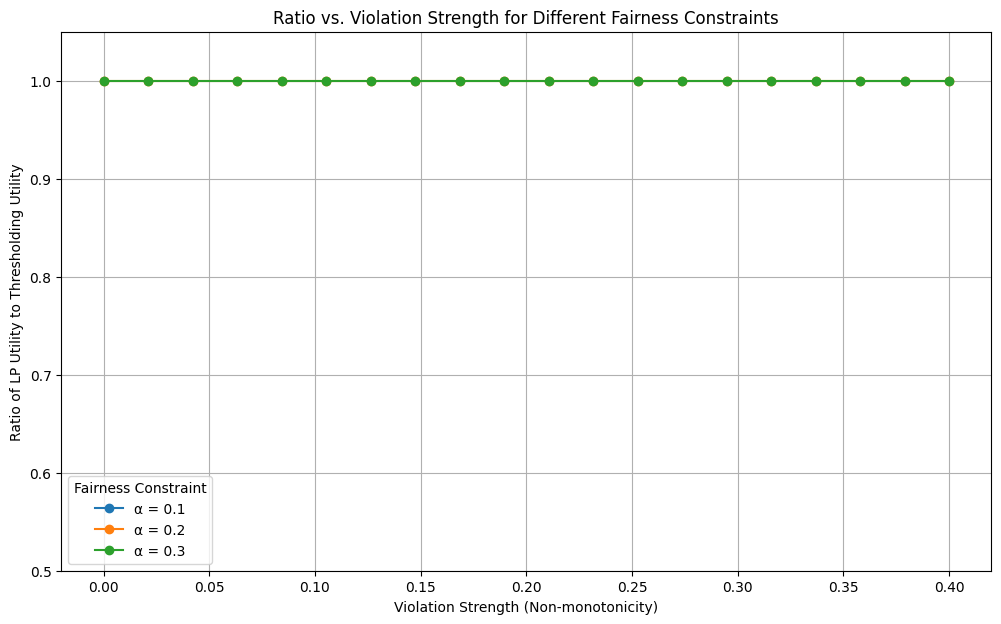

In [ ]:
# --- Experiment 2b: Robustness (Price of Simplicity) ---
# We violate Assumption 1 and compare
# the best simple Threshold policy vs the true Optimal LP policy.

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
from scipy.optimize import linprog
from scipy.stats import norm
import sys
import os # Needed for os.devnull
import matplotlib.pyplot as plt

# Modified helper functions for non-monotonicity
def p_success_modified(x, mode='linear', violation_strength=0):
    if mode == 'linear':
        base_p = np.clip((x - X_MIN) / (X_MAX - X_MIN), 0, 1)
        non_monotonic_component = violation_strength * np.sin(x * np.pi / (X_MAX - X_MIN) * 2)
        return np.clip(base_p + non_monotonic_component, 0, 1)
    else:
        return 1 / (1 + np.exp(-0.4 * (x-(X_MAX-X_MIN)/2)))

def get_metrics_modified(x, params, p_mode='linear', violation_strength=0):
    check_assumptions(params)
    # Fixed: Use 'violation_strength' parameter instead of undefined 'vi_strength'
    p = p_success_modified(x, mode=p_mode, violation_strength=violation_strength)
    eu = p * params['U_PLUS'] + (1 - p) * params['U_MINUS']
    ed = p * params['C_PLUS'] + (1 - p) * params['C_MINUS']
    return eu, ed

#synthetic parameters
np.random.seed(1066)
X_MIN = 0
X_MAX = 100
W_A = 0.7 #weight of group A
W_B = 1 - W_A #weight of group B
MEAN_Adv_group = 80
MEAN_disAdv_group = 60
sigma = 30

U_PLUS = 2
U_MINUS = -20
C_PLUS = 2
C_MINUS = -10

violation_strengths = np.linspace(0.0, 0.4, 20) # 20 steps from 0.0 to 0.4
alphas_to_plot = [0.1, 0.2, 0.3]
pos_results_monotonicity = {alpha: [] for alpha in alphas_to_plot}
pos_results = {alpha: [] for alpha in alphas_to_plot} # Also include for completeness if used elsewhere

# Prepare data for calculations
x_values = np.arange(X_MIN, X_MAX + 1)
input_dist = get_data('synthetic')

# Iterate through the defined range of violation_strengths values
# The outer tqdm should also have leave=False to ensure it cleans up properly.
with open(os.devnull, 'w') as fnull:
    original_stdout = sys.stdout
    original_stderr = sys.stderr
    sys.stdout = fnull
    sys.stderr = fnull

    for vi_strength in tqdm(violation_strengths, desc="Processing violation strengths", leave=False):
        current_cfg = {
            'U_PLUS': U_PLUS,
            'U_MINUS': U_MINUS,
            'C_PLUS': C_PLUS,
            'C_MINUS': C_MINUS,
            'p': 'linear'
        }

        # Use the modified get_metrics function with the current violation strength
        eu_vals, ed_vals = get_metrics_modified(x_values, current_cfg, current_cfg['p'], violation_strength=vi_strength)

        for alpha in alphas_to_plot:
            u_th, _ = solve_opt_fair(alpha, input_dist, x_values, eu_vals, ed_vals, speed='fast')
            u_lp, _ = solve_opt_fair_LP(alpha, input_dist, x_values, eu_vals, ed_vals)

            if u_th is not None and u_lp is not None and u_lp > 0:
                pos_ratio = u_th / u_lp
                pos_results_monotonicity[alpha].append(pos_ratio)
            else:
                pos_results_monotonicity[alpha].append(np.nan)

    sys.stdout = original_stdout
    sys.stderr = original_stderr

# Plot Price of Simplicity vs violation_strength
plt.figure(figsize=(12, 7))

for alpha, pos_ratios in pos_results_monotonicity.items():
    # Filter out NaN values for plotting to handle infeasible points gracefully
    valid_v_strengths = [violation_strengths[i] for i, val in enumerate(pos_ratios) if not np.isnan(val)]
    valid_pos_ratios = [val for val in pos_ratios if not np.isnan(val)]
    plt.plot(valid_v_strengths, valid_pos_ratios, marker='o', linestyle='-', label=f'α = {alpha}')

plt.xlabel('Violation Strength (Non-monotonicity)')
plt.ylabel('Ratio of LP Utility to Thresholding Utility')
plt.title('Ratio vs. Violation Strength for Different Fairness Constraints')
plt.grid(True)
plt.legend(title="Fairness Constraint")
plt.ylim(0.5, 1.05) # Adjust y-axis limit for better visualization, as PoS <= 1
plt.show()

## --- Experiment 3: Long-Term Convergence ---

Running Multi-step Simulation...


Searching Threshold A: 100%|█████████████████| 102/102 [00:00<00:00, 248.93it/s]


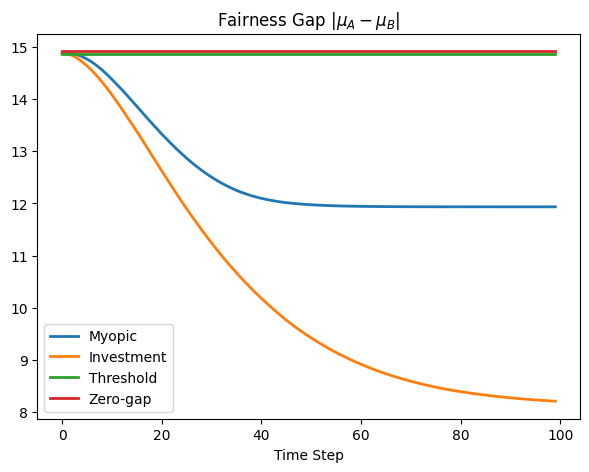

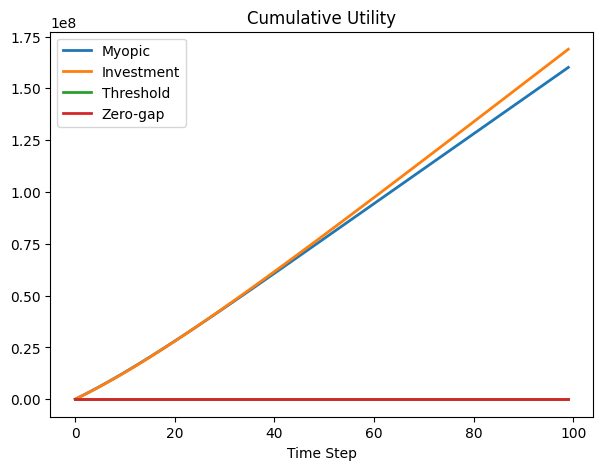

In [50]:
import numpy as np
import matplotlib.pyplot as plt

def check_assumptions(params):
    """Verifies that parameters satisfy paper assumptions."""
    ratio_u = params['U_PLUS'] / params['U_MINUS']
    ratio_c = params['C_PLUS'] / params['C_MINUS']
    # print(f"Assumption 2 Check: {ratio_u:.2f} > {ratio_c:.2f} ?") # Suppress this print statement
    if ratio_u < ratio_c:
        # print("❌ Assumption 2 VIOLATED. Change Parameters.") # Suppress this print statement
        # print('U+=',params['U_PLUS']) # Suppress this print statement
        # print('U-=',params['U_MINUS']) # Suppress this print statement
        # print('C+=',params['C_PLUS']) # Suppress this print statement
        # print('C-=',params['C_MINUS']) # Suppress this print statement
        pass # Keep a pass to avoid empty if block syntax error

import numpy as np
import matplotlib.pyplot as plt

X_MIN = 0
X_MAX = 100
W_A = 0.7 #weight of group A
W_B = 1 - W_A #weight of group B
MEAN_Adv_group = 90
MEAN_disAdv_group = 70
sigma = 30

def simulate_multistep(policy, T=100, n_agents=1000000):
    cfg = {'U_PLUS': 2, 'U_MINUS': -2, 'C_PLUS': 2, 'C_MINUS': -1}

    # Init Populations
    pop_A = (np.random.normal(MEAN_Adv_group, sigma, int(n_agents*W_A)).clip(X_MIN, X_MAX)).astype(int)
    pop_B = (np.random.normal(MEAN_disAdv_group, sigma, int(n_agents*W_B)).clip(X_MIN, X_MAX)).astype(int)

    history = {'gap': [], 'util': []}
    cum_util = 0

    for t in range(T):
        # 1. Record State
        gap = np.abs(np.mean(pop_A) - np.mean(pop_B))
        history['gap'].append(gap)
        history['util'].append(cum_util)

        # 2. Calculate Selection Masks
        # Precompute metrics for all x
        x_rng = np.arange(X_MAX + 1)
        eu, ed = get_metrics(x_rng, cfg, 'linear')
        p_vals = p_success(x_rng, 'linear')

        # Initialize masks to be empty and of the correct size for the current populations
        mask_A = np.zeros(len(pop_A), dtype=bool)
        mask_B = np.zeros(len(pop_B), dtype=bool)

        if policy == 'Myopic':
            mask_A = eu[pop_A] > 0
            mask_B = eu[pop_B] > 0

        elif policy == 'Investment':
            mask_A = ed[pop_A] > 0
            mask_B = ed[pop_B] > 0

        elif 'Threshold' in policy:
            # Estimate Distributions
            d_A, _ = np.histogram(pop_A, bins=np.arange(X_MAX+2), density=True)
            d_B, _ = np.histogram(pop_B, bins=np.arange(X_MAX+2), density=True)

            # Solve with alpha=0.01
            # solve_threshold_policy returns (best_fair_u, best_thresholds)
            # best_thresholds can be None if no valid threshold found
            _, th = solve_opt_fair(0.01, [d_A, d_B], x_rng, eu, ed, speed='fast')

            if th:
                tA, tB = th
                mask_A = pop_A >= tA
                mask_B = pop_B >= tB
            # If th is None, mask_A and mask_B remain empty (initialized above) of correct size

        # 3. Apply Outcome
        # Utility
        step_util = np.sum(eu[pop_A[mask_A]]) + np.sum(eu[pop_B[mask_B]])
        cum_util += step_util

        # Score Updates
        # Group A
        if np.any(mask_A):
            succ = np.random.rand(mask_A.sum()) < p_vals[pop_A[mask_A]]
            delta = np.where(succ, cfg['C_PLUS'], cfg['C_MINUS'])
            pop_A[mask_A] = np.clip(pop_A[mask_A] + delta, X_MIN, X_MAX)

        # Group B
        if np.any(mask_B):
            succ = np.random.rand(mask_B.sum()) < p_vals[pop_B[mask_B]]
            delta = np.where(succ, cfg['C_PLUS'], cfg['C_MINUS'])
            pop_B[mask_B] = np.clip(pop_B[mask_B] + delta, X_MIN, X_MAX)

    return history

# Run Simulation
policies = ['Myopic', 'Investment', 'Threshold', 'Zero-gap']
results = {}

print("Running Multi-step Simulation...")
for pol in policies:
    results[pol] = simulate_multistep(pol)

# Plot Results
plt.figure(figsize=(7, 5))

for pol, res in results.items():
    plt.plot(res['gap'], label=pol, linewidth=2)

plt.title(r'Fairness Gap $|\mu_A - \mu_B|$')
plt.xlabel('Time Step')
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))

for pol, res in results.items():
    plt.plot(res['util'], label=pol, linewidth=2)

plt.title('Cumulative Utility')
plt.xlabel('Time Step')
plt.legend()
plt.show()